# 05 — Callaway & Sant'Anna Staggered DiD

NYC (Local Law 18, Sep 2023) and Florence (historic-centre ban, Oct 2023) are
treated in adjacent but distinct months, with Amsterdam, Lisbon, Vienna and
Barcelona as never-treated controls. That is a staggered design, so we use the
**actual** Callaway & Sant'Anna (2021) group-time ATT estimator rather than a
single pooled TWFE interaction.

For each treated cohort *g* (treatment month) and month *t*:

$$ATT(g,t) = \big[\mathbb{E}(Y_t - Y_{g-1}\mid G=g)\big]-\big[\mathbb{E}(Y_t - Y_{g-1}\mid \text{never-treated})\big]$$

aggregated to an event-study path. Pre-treatment event months are placebo checks.

> **Inference caveat.** There are only 6 cities, hence only 6 clusters. The
> city-clustered bootstrap CIs below are therefore *indicative* — with so few
> clusters they are wide and unstable by construction. The dynamic **point**
> path (a clean −80%+ drop for NYC) is the credible takeaway; treat the bands as
> a lower bound on uncertainty, not a precise interval.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("../src").resolve()))
from cs_did import cs_did

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

DATA_FILE = "city_month_panel.parquet"   # synthetic panel (see README on data availability)
panel = pd.read_parquet(DATA_DIR / DATA_FILE)
panel["month"] = pd.to_datetime(panel["month"])
print(f"Panel: {panel.shape}  |  Cities: {sorted(panel['city'].unique())}")
print(f"Months: {panel['month'].min().date()} → {panel['month'].max().date()}")

Panel: (288, 15)  |  Cities: ['Amsterdam', 'Barcelona', 'Florence', 'Lisbon', 'New York City', 'Vienna']
Months: 2021-01-01 → 2024-12-01


## Define cohorts (treatment month index)

NYC is treated at month index 32 (Sep 2023), Florence at 33 (Oct 2023).
Control cities get cohort = NaN (never treated).

In [2]:
NYC_G, FLO_G = 32, 33   # month_idx of enforcement

panel["cohort"] = np.nan
panel.loc[panel["city"] == "New York City", "cohort"] = NYC_G
panel.loc[panel["city"] == "Florence",      "cohort"] = FLO_G

print(panel.drop_duplicates("city")[["city", "cohort"]].to_string(index=False))
print(f"\nNever-treated controls: "
      f"{panel[panel['cohort'].isna()]['city'].nunique()} cities")

         city  cohort
New York City    32.0
     Florence    33.0
    Amsterdam     NaN
       Lisbon     NaN
       Vienna     NaN
    Barcelona     NaN

Never-treated controls: 4 cities


## Estimate ATT(g, t) — outcome: log listings

In [3]:
res = cs_did(
    panel, unit="city", time="month_idx", outcome="log_listings",
    cohort="cohort", control_group="nevertreated",
    n_boot=1000, seed=42,
)
es = res["event_study"]

att = res["overall_att"]
print(f"Overall ATT on log listings: {att:+.4f}  "
      f"→ {(np.exp(att)-1)*100:+.1f}% in levels")
print(f"  City-clustered bootstrap 95% CI "
      f"[{res['overall_ci'][0]:+.4f}, {res['overall_ci'][1]:+.4f}]")
print()
# Show a compact event window around treatment
window = es[es["event_time"].between(-6, 9)]
print(window[["event_time", "att", "ci_lo", "ci_hi"]].round(3).to_string(index=False))

Overall ATT on log listings: -1.2162  → -70.4% in levels
  City-clustered bootstrap 95% CI [-1.9233, -0.5112]

 event_time    att  ci_lo  ci_hi
         -6 -0.041 -0.285  0.181
         -5 -0.123 -0.397  0.177
         -4 -0.136 -0.222 -0.021
         -3 -0.298 -0.420 -0.179
         -2 -0.132 -0.421  0.170
          0 -1.269 -2.058 -0.532
          1 -1.324 -2.019 -0.595
          2 -1.187 -1.958 -0.485
          3 -1.181 -1.911 -0.491
          4 -1.119 -1.792 -0.483
          5 -1.164 -1.862 -0.544
          6 -1.212 -1.727 -0.651
          7 -1.299 -2.170 -0.388
          8 -1.238 -1.850 -0.660
          9 -1.218 -2.094 -0.358


## Event-study plot

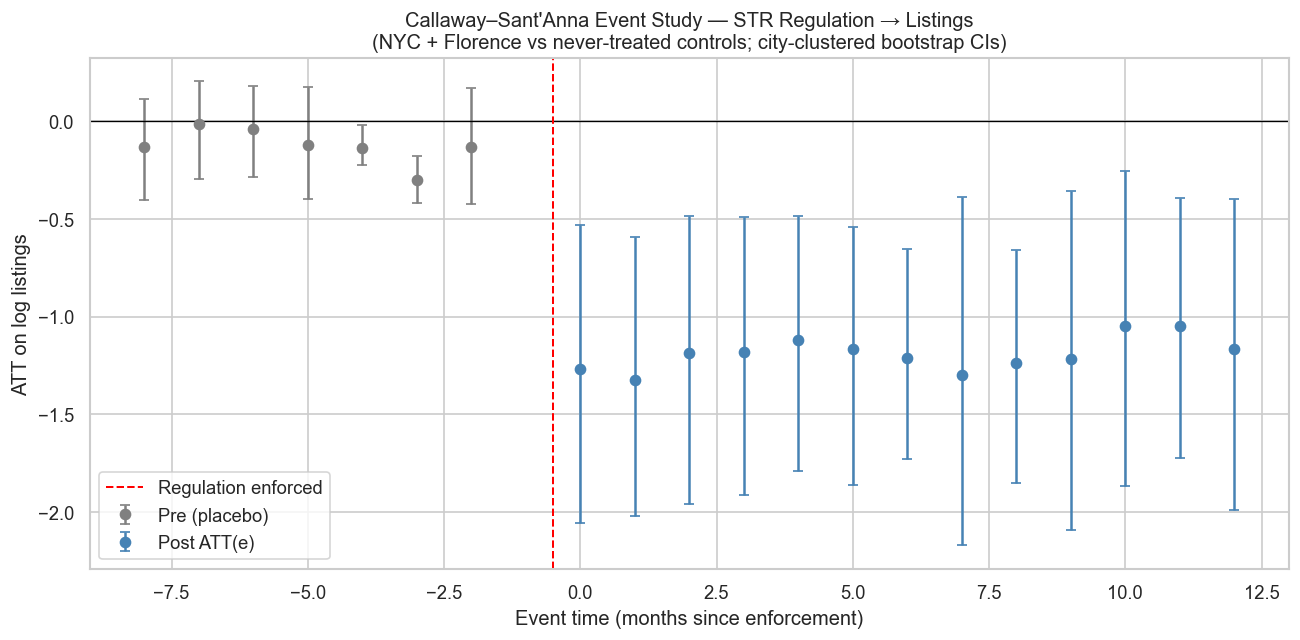

In [4]:
w = es[es["event_time"].between(-8, 12)].copy()
fig, ax = plt.subplots(figsize=(11, 5.5))
pre_m, post_m = w["event_time"] < 0, w["event_time"] >= 0
for m, color, lab in [(pre_m, "gray", "Pre (placebo)"), (post_m, "steelblue", "Post ATT(e)")]:
    ax.errorbar(w.loc[m, "event_time"], w.loc[m, "att"],
                yerr=[w.loc[m, "att"] - w.loc[m, "ci_lo"], w.loc[m, "ci_hi"] - w.loc[m, "att"]],
                fmt="o", color=color, capsize=3, label=lab)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(-0.5, color="red", ls="--", lw=1.2, label="Regulation enforced")
ax.set_xlabel("Event time (months since enforcement)")
ax.set_ylabel("ATT on log listings")
ax.set_title("Callaway–Sant'Anna Event Study — STR Regulation → Listings\n(NYC + Florence vs never-treated controls; city-clustered bootstrap CIs)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_cs_event_study.png", bbox_inches="tight")
plt.show()

## Interpretation

- The point path shows **no pre-trend** and a **sharp, immediate drop** in
  listings at enforcement, consistent with NYC's documented ~80% collapse in
  active listings within weeks of LL18.
- C-S keeps NYC and Florence from contaminating each other's control group —
  the static TWFE in notebook 04 would let the already-treated city act as a
  control for the later one. With effects this large and this dynamic, that is
  exactly where TWFE breaks.
- **Inference honesty:** with 6 clusters the bootstrap bands are wide; the
  identification, not the CI width, is the point of this notebook. A real-world
  version with the full Inside Airbnb city roster (dozens of cities) would give
  proper clustered inference.